# Verificador LTL con Autómatas de Büchi
## *Model Checking de Sistemas Reactivos*

**Proyecto Final · Teoría de Autómatas · Jorge Vasquez**

---

Este proyecto implementa un **model checker** basado en Autómatas de Büchi.
Dado un sistema reactivo y una propiedad expresada en LTL (Lógica Temporal Lineal),
el verificador determina si la propiedad se cumple en **todos** los comportamientos
posibles del sistema, incluyendo ejecuciones infinitas.

Si la propiedad es violada, el sistema produce un **contraejemplo**: un comportamiento
concreto del sistema donde la propiedad falla.

### Pipeline del verificador

```
Sistema (Kripke)  +  Propiedad φ (LTL)
         │                   │
         │            Negar: ¬φ
         │                   │
         │         Convertir ¬φ → Büchi A
         │                   │
         └──── Producto M × A ────┘
                      │
            Nested DFS: ¿hay ciclo aceptante?
                      │
          ┌───────────┴────────────┐
          ✅ Verificado          ❌ Violado + contraejemplo
```

In [1]:
# ── Dependencias ──────────────────────────────────────────────
import re
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Set, Dict, List, Tuple, FrozenSet, Optional

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

---
## Módulo 1: Árbol de Sintaxis Abstracta (AST) para LTL

Representamos fórmulas LTL como árboles. Cada clase es un nodo del árbol:

| Clase | Operador | Lectura |
|---|---|---|
| `Atom(p)` | — | proposición atómica *p* |
| `Not(φ)` | `!` | negación |
| `And(φ,ψ)` | `&` | conjunción |
| `Or(φ,ψ)` | `\|` | disyunción |
| `G(φ)` | `G` | *siempre* φ (Globally) |
| `F(φ)` | `F` | *eventualmente* φ (Finally) |

In [2]:
# ── AST de Fórmulas LTL ───────────────────────────────────────

class Formula:
    """Clase base para todas las fórmulas LTL."""
    pass

class Atom(Formula):
    def __init__(self, name: str):
        self.name = name
    def __repr__(self): return self.name
    def __eq__(self, o): return isinstance(o, Atom) and self.name == o.name
    def __hash__(self): return hash(('Atom', self.name))

class Not(Formula):
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'!{self.child}'
    def __eq__(self, o): return isinstance(o, Not) and self.child == o.child
    def __hash__(self): return hash(('Not', self.child))

class And(Formula):
    def __init__(self, left: Formula, right: Formula):
        self.left, self.right = left, right
    def __repr__(self): return f'({self.left} & {self.right})'
    def __eq__(self, o): return isinstance(o, And) and self.left == o.left and self.right == o.right
    def __hash__(self): return hash(('And', self.left, self.right))

class Or(Formula):
    def __init__(self, left: Formula, right: Formula):
        self.left, self.right = left, right
    def __repr__(self): return f'({self.left} | {self.right})'
    def __eq__(self, o): return isinstance(o, Or) and self.left == o.left and self.right == o.right
    def __hash__(self): return hash(('Or', self.left, self.right))

class G(Formula):  # Globally / Always
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'G({self.child})'
    def __eq__(self, o): return isinstance(o, G) and self.child == o.child
    def __hash__(self): return hash(('G', self.child))

class F(Formula):  # Finally / Eventually
    def __init__(self, child: Formula):
        self.child = child
    def __repr__(self): return f'F({self.child})'
    def __eq__(self, o): return isinstance(o, F) and self.child == o.child
    def __hash__(self): return hash(('F', self.child))

print('✓ AST definido')

✓ AST definido


---
## Módulo 2: Parser LTL

Convierte un string como `"G F verde"` o `"G !(critica_A & critica_B)"` en un AST.

Usa un parser recursivo descendente con la siguiente gramática:
```
expr  → or
or    → and ('|' and)*
and   → unary ('&' unary)*
unary → '!' unary | 'G' unary | 'F' unary | '(' expr ')' | atom
```

In [3]:
# ── Parser LTL ────────────────────────────────────────────────

def tokenize(s: str) -> list:
    """Divide el string en tokens LTL."""
    return re.findall(r'G\b|F\b|!|&|\||\(|\)|[a-zA-Z_][a-zA-Z0-9_]*', s)

def parse_ltl(s: str) -> Formula:
    """
    Parsea una fórmula LTL desde string.
    Ejemplos: 'G F verde', 'G !(critica_A & critica_B)', 'F critica_A'
    """
    tokens = tokenize(s)
    pos = [0]

    def peek():
        return tokens[pos[0]] if pos[0] < len(tokens) else None

    def consume():
        t = tokens[pos[0]]; pos[0] += 1; return t

    def parse_expr(): return parse_or()

    def parse_or():
        left = parse_and()
        while peek() == '|':
            consume()
            left = Or(left, parse_and())
        return left

    def parse_and():
        left = parse_unary()
        while peek() == '&':
            consume()
            left = And(left, parse_unary())
        return left

    def parse_unary():
        t = peek()
        if t == '!': consume(); return Not(parse_unary())
        if t == 'G': consume(); return G(parse_unary())
        if t == 'F': consume(); return F(parse_unary())
        if t == '(':
            consume()
            e = parse_expr()
            consume()  # ')'
            return e
        return Atom(consume())

    return parse_expr()


# ── NNF: Forma Normal Negativa ─────────────────────────────────
# Empuja todas las negaciones hacia los átomos.
# Reglas: ¬¬φ→φ, ¬(φ&ψ)→(¬φ|¬ψ), ¬Gφ→F¬φ, ¬Fφ→G¬φ

def to_nnf(f: Formula) -> Formula:
    """Convierte fórmula a Forma Normal Negativa."""
    if isinstance(f, Atom):
        return f
    if isinstance(f, Not):
        c = f.child
        if isinstance(c, Atom):  return f
        if isinstance(c, Not):   return to_nnf(c.child)
        if isinstance(c, And):   return Or(to_nnf(Not(c.left)), to_nnf(Not(c.right)))
        if isinstance(c, Or):    return And(to_nnf(Not(c.left)), to_nnf(Not(c.right)))
        if isinstance(c, G):     return F(to_nnf(Not(c.child)))
        if isinstance(c, F):     return G(to_nnf(Not(c.child)))
    if isinstance(f, And): return And(to_nnf(f.left), to_nnf(f.right))
    if isinstance(f, Or):  return Or(to_nnf(f.left), to_nnf(f.right))
    if isinstance(f, G):   return G(to_nnf(f.child))
    if isinstance(f, F):   return F(to_nnf(f.child))
    return f


# ── Tests del parser ──────────────────────────────────────────
assert repr(parse_ltl('G F verde')) == 'G(F(verde))'
assert repr(parse_ltl('G !(a & b)')) == 'G(!(a & b))'
assert repr(to_nnf(Not(G(Atom('p'))))) == 'F(!p)'
assert repr(to_nnf(Not(F(Atom('p'))))) == 'G(!p)'
assert repr(to_nnf(Not(Not(Atom('p'))))) == 'p'
print('✓ Parser y NNF OK')

✓ Parser y NNF OK


---
## Módulo 3: Autómata de Büchi

Un **Autómata de Büchi no determinista** se define como:

$$A = (Q,\; \Sigma,\; \delta,\; q_0,\; F)$$

donde $F \subseteq Q$ es el conjunto de **estados de aceptación**.

El criterio de aceptación es:
$$\rho \text{ es aceptante} \iff \text{Inf}(\rho) \cap F \neq \emptyset$$

Es decir, la ejecución es aceptada si **pasa infinitamente muchas veces** por algún estado de $F$.

Cada transición tiene un **guardia** — un conjunto de literales (átomos o negaciones de átomos)
que deben ser satisfechos por las etiquetas del estado actual para que la transición se active.

In [4]:
# ── Autómata de Büchi ─────────────────────────────────────────

class BuchiAutomaton:
    def __init__(self):
        self.states: List[int] = []
        self.initial: int = 0
        self.transitions: List[Tuple] = []  # (from_state, guard: frozenset, to_state)
        self.accepting: Set[int] = set()

    def successors(self, state: int, labels: Set[str]) -> List[int]:
        """Retorna estados sucesores dado el estado actual y las etiquetas verdaderas."""
        return [t for (f, guard, t) in self.transitions
                if f == state and guard_satisfied(guard, labels)]

    def __repr__(self):
        return (f'Büchi(states={len(self.states)}, '
                f'transitions={len(self.transitions)}, '
                f'accepting={self.accepting})')


def guard_satisfied(guard: FrozenSet, labels: Set[str]) -> bool:
    """
    Verifica si las etiquetas satisfacen la guardia.
    Guardia vacía → siempre satisfecha.
    Átomo p en guardia → p debe estar en labels.
    !p en guardia → p NO debe estar en labels.
    """
    for lit in guard:
        if isinstance(lit, Atom):
            if lit.name not in labels: return False
        elif isinstance(lit, Not) and isinstance(lit.child, Atom):
            if lit.child.name in labels: return False
    return True

print('✓ BuchiAutomaton definido')

✓ BuchiAutomaton definido


---
## Módulo 4: Conversión LTL → Autómata de Büchi

Dado $\neg\varphi$ en NNF, construimos un Büchi que acepta exactamente las trazas
donde $\varphi$ **falla**.

Para el POC implementamos construcciones explícitas para los patrones más comunes:

| Patrón | Büchi | Semántica |
|---|---|---|
| `F φ` | espera hasta que φ → acepta | *eventualmente* φ |
| `G φ` | acepta mientras φ | *siempre* φ |
| `F(G φ)` | eventualmente se queda en φ | φ se vuelve *permanente* |
| `G(F φ)` | φ ocurre infinitamente | φ se repite *siempre* |
| `φ & ψ` | producto de Büchis | ambas deben cumplirse |
| `φ \| ψ` | unión de Büchis | al menos una debe cumplirse |

In [5]:
# ── LTL → Büchi (construcciones explícitas para POC) ──────────

def is_literal(f: Formula) -> bool:
    return isinstance(f, Atom) or (isinstance(f, Not) and isinstance(f.child, Atom))

def is_literal_conj(f: Formula) -> bool:
    """True si f es una conjunción de literales."""
    return is_literal(f) or (isinstance(f, And) and
                              is_literal_conj(f.left) and is_literal_conj(f.right))

def get_literals(f: Formula) -> list:
    """Extrae lista de literales de una conjunción."""
    if is_literal(f): return [f]
    if isinstance(f, And): return get_literals(f.left) + get_literals(f.right)
    return []


def buchi_eventually(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para F(phi): eventualmente phi.
    q0 (inicial) -any-> q0   (esperando)
    q0           -phi-> q1   (phi ocurrió)
    q1 (acepta)  -any-> q1   (sink aceptante)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_any, 1),
    ]
    return b


def buchi_always(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para G(phi): siempre phi.
    q0 (inicial, acepta) -phi-> q0
    (se atasca si phi falla → no hay run infinita)
    """
    b = BuchiAutomaton()
    b.states = [0]
    b.initial = 0
    b.accepting = {0}
    guard_phi = frozenset(get_literals(phi))
    b.transitions = [(0, guard_phi, 0)]
    return b


def buchi_eventually_always(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para F(G(phi)): eventualmente phi vale para siempre.
    q0 (inicial) -any-> q0   (esperando comprometerse)
    q0           -phi-> q1   (comprometido: phi vale ahora)
    q1 (acepta)  -phi-> q1   (permanece comprometido)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_phi, 1),
    ]
    return b


def buchi_always_eventually(phi: Formula) -> BuchiAutomaton:
    """
    Büchi para G(F(phi)): phi ocurre infinitamente a menudo.
    q0 (inicial) -any-> q0   (esperando phi)
    q0           -phi-> q1   (phi ocurrió)
    q1 (acepta)  -any-> q0   (volver a esperar)
    q1           -phi-> q1   (phi de nuevo)
    """
    b = BuchiAutomaton()
    b.states = [0, 1]
    b.initial = 0
    b.accepting = {1}
    guard_phi = frozenset(get_literals(phi))
    guard_any = frozenset()
    b.transitions = [
        (0, guard_any, 0),
        (0, guard_phi, 1),
        (1, guard_any, 0),
        (1, guard_phi, 1),
    ]
    return b


def ltl_to_buchi(formula: Formula) -> BuchiAutomaton:
    """
    Convierte fórmula LTL (en NNF) a Autómata de Büchi.
    Soporta: F(lit), G(lit), F(G(lit)), G(F(lit)), And, Or de los anteriores.
    """
    f = to_nnf(formula)

    # Átomo o negación de átomo
    if is_literal(f):
        return buchi_always(f)  # G(lit): lit debe valer siempre

    # F(conjunción de literales)
    if isinstance(f, F) and is_literal_conj(f.child):
        return buchi_eventually(f.child)

    # G(conjunción de literales)
    if isinstance(f, G) and is_literal_conj(f.child):
        return buchi_always(f.child)

    # F(G(conjunción de literales))
    if isinstance(f, F) and isinstance(f.child, G) and is_literal_conj(f.child.child):
        return buchi_eventually_always(f.child.child)

    # G(F(conjunción de literales))
    if isinstance(f, G) and isinstance(f.child, F) and is_literal_conj(f.child.child):
        return buchi_always_eventually(f.child.child)

    raise NotImplementedError(
        f'Patrón no soportado en POC: {f}\n'
        f'Soportados: F(p), G(p), F(G(p)), G(F(p)) donde p es conjunción de literales.'
    )


# ── Tests ─────────────────────────────────────────────────────
b_test = ltl_to_buchi(F(Atom('p')))
assert 1 in b_test.accepting
assert len(b_test.states) == 2

b_test2 = ltl_to_buchi(to_nnf(Not(G(F(Atom('p'))))))
assert len(b_test2.accepting) == 1

print('✓ LTL → Büchi OK')

✓ LTL → Büchi OK


---
## Módulo 4B: Algoritmo General GPVW — LTL → Büchi

El algoritmo de **Gerth, Peled, Vardi y Wolper (1995)** construye un Büchi para **cualquier** fórmula LTL, sin patrones hardcodeados.

### Idea central

Cada estado del Büchi es un **conjunto de obligaciones** — fórmulas LTL que deben cumplirse desde ese momento. La construcción expande una obligación a la vez:

| Fórmula | Expansión |
|---|---|
| $p$ (átomo) | añadir $p$ a la guardia de la transición |
| $\varphi \wedge \psi$ | ambas obligaciones pasan al estado actual |
| $\varphi \vee \psi$ | bifurcación: un sucesor con $\varphi$, otro con $\psi$ |
| $\mathbf{G}\,\varphi$ | $\varphi$ ahora **+** $\mathbf{G}\,\varphi$ en el siguiente estado |
| $\mathbf{F}\,\varphi$ | bifurcación: $\varphi$ ahora (F cumplida) ó $\mathbf{F}\,\varphi$ siguiente (F pendiente) |

### Autómata de Büchi Generalizado (GNBA)

El algoritmo produce directamente un **GNBA** — una variante donde hay múltiples condiciones de aceptación $\{F_1, F_2, \ldots, F_k\}$, una por cada $\mathbf{F}$-subfórmula. Una ejecución es aceptante iff visita infinitamente a menudo **cada** $F_i$.

### Desgeneralización GNBA → NBA

Se multiplican los estados por $k$ (el número de condiciones):
$$\text{Estado nuevo}: (q, i) \quad q \in Q,\; i \in \{0,\ldots,k-1\}$$
El nivel $i$ indica "la próxima condición a satisfacer". Al completar una ronda completa se vuelve al nivel $0$ — y los estados en nivel $0$ son los aceptantes del Büchi estándar.

In [6]:
# ── GPVW: Algoritmo General LTL → Büchi ───────────────────────

def collect_f_subformulas(phi: Formula) -> list:
    """Recopila todas las sub-fórmulas F(...) (sin duplicados, en orden)."""
    result, seen = [], set()
    def walk(f):
        if isinstance(f, F) and f not in seen:
            seen.add(f); result.append(f)
        if isinstance(f, (Not, G, F)): walk(f.child)
        if isinstance(f, (And, Or)):   walk(f.left); walk(f.right)
    walk(phi)
    return result


def expand_obligations(obs: frozenset) -> list:
    """
    Expande un conjunto de obligaciones LTL.
    Retorna lista de (guard: frozenset[literal], next_obs: frozenset[Formula]).

    Cada par es una alternativa de satisfacción (Or y F producen bifurcaciones).
    """
    def expand(todo, processed, guard, next_obs):
        if not todo:
            return [(frozenset(guard), frozenset(next_obs))]

        f = next(iter(todo)); todo = todo - {f}
        if f in processed:
            return expand(todo, processed, guard, next_obs)
        processed = processed | {f}

        if isinstance(f, Atom):
            if Not(f) in guard: return []          # contradicción
            return expand(todo, processed, guard | {f}, next_obs)

        if isinstance(f, Not) and isinstance(f.child, Atom):
            if f.child in guard: return []          # contradicción
            return expand(todo, processed, guard | {f}, next_obs)

        if isinstance(f, And):
            return expand(todo | {f.left, f.right}, processed, guard, next_obs)

        if isinstance(f, Or):
            return (expand(todo | {f.left},  processed, guard, next_obs) +
                    expand(todo | {f.right}, processed, guard, next_obs))

        if isinstance(f, G):    # φ ahora + G(φ) en el siguiente
            return expand(todo | {f.child}, processed, guard, next_obs | {f})

        if isinstance(f, F):    # bifurcación: cumplida ahora | pendiente al siguiente
            fulfilled = expand(todo | {f.child}, processed, guard, next_obs)
            pending   = expand(todo,              processed, guard, next_obs | {f})
            return fulfilled + pending

        return expand(todo, processed, guard, next_obs)  # fórmula no reconocida

    return expand(frozenset(obs), frozenset(), frozenset(), frozenset())


def ltl_to_gnba(phi: Formula) -> dict:
    """
    Construye un GNBA para phi (en NNF) mediante el tableau GPVW.
    Cada estado = frozenset de obligaciones LTL.
    """
    f_subs = collect_f_subformulas(phi)
    states, state_map, transitions = [], {}, []

    def get_state(obs):
        if obs not in state_map:
            state_map[obs] = len(states); states.append(obs)
        return state_map[obs]

    init_id  = get_state(frozenset([phi]))
    worklist = [init_id]; processed = set()

    while worklist:
        sid = worklist.pop()
        if sid in processed: continue
        processed.add(sid)

        for (guard, next_obs) in expand_obligations(states[sid]):
            pos_atoms = {f.name for f in guard if isinstance(f, Atom)}
            neg_atoms = {f.child.name for f in guard
                         if isinstance(f, Not) and isinstance(f.child, Atom)}
            if pos_atoms & neg_atoms: continue   # guardia inconsistente

            nid = get_state(next_obs)
            transitions.append((sid, guard, nid))
            if nid not in processed: worklist.append(nid)

    # Condición de aceptación para cada F(φ): estados donde F(φ) NO está pendiente
    acc_sets = [{i for (i, obs) in enumerate(states) if fs not in obs}
                for fs in f_subs]

    return {'states': states, 'initial': init_id,
            'transitions': transitions, 'acc_sets': acc_sets,
            'n_states': len(states)}


def degeneralize_gnba(gnba: dict) -> dict:
    """
    Convierte GNBA → NBA estándar.
    Estados: (q, nivel) donde nivel indica qué condición de aceptación se busca.
    """
    acc_sets = gnba['acc_sets']; n = gnba['n_states']; k = len(acc_sets)

    if k == 0:
        return {'initial': gnba['initial'], 'transitions': gnba['transitions'],
                'accepting': set(range(n)), 'n_states': n}
    if k == 1:
        return {'initial': gnba['initial'], 'transitions': gnba['transitions'],
                'accepting': acc_sets[0], 'n_states': n}

    # Mapeo (q, nivel) → id lineal
    new_map = {(q, i): q * k + i for q in range(n) for i in range(k)}

    new_trans = [
        (new_map[(fq, i)], guard,
         new_map[(tq, (i + 1) % k if fq in acc_sets[i] else i)])
        for (fq, guard, tq) in gnba['transitions']
        for i in range(k)
    ]
    return {'initial':     new_map[(gnba['initial'], 0)],
            'transitions': new_trans,
            'accepting':   {new_map[(q, 0)] for q in range(n)},
            'n_states':    n * k}


def ltl_to_buchi_general(phi: Formula) -> BuchiAutomaton:
    """
    Construye un Autómata de Büchi para phi usando el algoritmo GPVW.
    Funciona para cualquier fórmula LTL (no solo patrones fijos).
    """
    phi = to_nnf(phi)
    nba = degeneralize_gnba(ltl_to_gnba(phi))

    b = BuchiAutomaton()
    b.states      = list(range(nba['n_states']))
    b.initial     = nba['initial']
    b.transitions = nba['transitions']
    b.accepting   = nba['accepting']
    return b


# ── Tests GPVW ────────────────────────────────────────────────
_bg = ltl_to_buchi_general(to_nnf(Not(G(F(Atom('p'))))))   # F(G(!p))
assert len(_bg.accepting) > 0, 'Debe tener estados aceptantes'
assert len(_bg.states) >= 2,   'F(G(!p)) necesita al menos 2 estados'

_bg2 = ltl_to_buchi_general(F(And(Atom('a'), Atom('b'))))   # F(a & b)
assert len(_bg2.accepting) > 0, 'F(a&b) debe tener estados aceptantes'

print(f'✓ GPVW OK')
print(f'  F(G(!p)): {len(_bg.states)} estados, {len(_bg.transitions)} trans, '
      f'aceptantes={_bg.accepting}')
print(f'  F(a & b): {len(_bg2.states)} estados, {len(_bg2.transitions)} trans')

✓ GPVW OK
  F(G(!p)): 2 estados, 3 trans, aceptantes={1}
  F(a & b): 2 estados, 3 trans


---
## Módulo 5: Estructura de Kripke (el Sistema)

Una **Estructura de Kripke** modela el sistema a verificar:

$$M = (S,\; s_0,\; R,\; L)$$

| Componente | Descripción |
|---|---|
| $S$ | Conjunto finito de estados |
| $s_0 \in S$ | Estado inicial |
| $R \subseteq S \times S$ | Relación de transición |
| $L : S \to 2^{AP}$ | Función de etiquetado (qué proposiciones son verdaderas en cada estado) |

In [7]:
# ── Estructura de Kripke ──────────────────────────────────────

class KripkeStructure:
    def __init__(self,
                 states: List[str],
                 initial: str,
                 transitions: List[Tuple[str, str]],
                 labels: Dict[str, Set[str]]):
        """
        states:      lista de nombres de estados
        initial:     estado inicial
        transitions: lista de pares (origen, destino)
        labels:      dict estado → conjunto de proposiciones verdaderas
        """
        self.states = states
        self.initial = initial
        self.transitions = transitions
        self.labels = labels

        # Validación
        all_states = set(states)
        assert initial in all_states, f'Estado inicial "{initial}" no está en states'
        for (s, t) in transitions:
            assert s in all_states, f'Estado "{s}" en transición no definido'
            assert t in all_states, f'Estado "{t}" en transición no definido'

    def successors(self, state: str) -> List[str]:
        return [t for (s, t) in self.transitions if s == state]

    def get_labels(self, state: str) -> Set[str]:
        return self.labels.get(state, set())

    def __repr__(self):
        return f'Kripke(states={self.states}, initial="{self.initial}")'


# ── Tests ─────────────────────────────────────────────────────
k_test = KripkeStructure(
    states=['s0', 's1'],
    initial='s0',
    transitions=[('s0', 's1'), ('s1', 's0')],
    labels={'s0': {'p'}, 's1': set()}
)
assert k_test.successors('s0') == ['s1']
assert 'p' in k_test.get_labels('s0')
print('✓ KripkeStructure OK')

✓ KripkeStructure OK


---
## Módulo 6: Autómata Producto M × A

El **autómata producto** combina el sistema y el Büchi en una sola estructura:

$$P = M \times A_{\neg\varphi}$$

- **Estados**: pares $(s, q)$ donde $s \in S$ (Kripke) y $q \in Q$ (Büchi)
- **Transición**: $(s, q) \to (s', q')$ si:
  - $s \to s'$ en el sistema, **y**
  - existe transición $q \xrightarrow{\text{guard}} q'$ en el Büchi con $L(s)$ satisfaciendo la guardia
- **Estados aceptantes**: $\{(s, q) \mid q \in F_A\}$

La construcción es **on-the-fly**: solo se generan los estados alcanzables desde el estado inicial.

In [8]:
# ── Autómata Producto ─────────────────────────────────────────

def product_automaton(kripke: KripkeStructure, buchi: BuchiAutomaton) -> dict:
    """
    Construye el producto M × A (solo estados alcanzables).
    Retorna dict con 'states', 'initial', 'transitions', 'accepting'.
    """
    prod_states = []       # lista de (kripke_state, buchi_state)
    prod_transitions = []  # lista de (from_id, to_id)
    prod_accepting = set() # ids de estados aceptantes
    prod_initial = []

    state_map = {}  # (k, b) → product_id

    def get_state(k, b):
        key = (k, b)
        if key not in state_map:
            sid = len(prod_states)
            prod_states.append(key)
            state_map[key] = sid
            if b in buchi.accepting:
                prod_accepting.add(sid)
        return state_map[key]

    # Estado inicial del producto
    init_id = get_state(kripke.initial, buchi.initial)
    prod_initial.append(init_id)

    # BFS sobre estados alcanzables
    visited = set()
    queue = [init_id]

    while queue:
        psid = queue.pop(0)
        if psid in visited: continue
        visited.add(psid)

        (k_s, b_s) = prod_states[psid]
        k_labels = kripke.get_labels(k_s)  # etiquetas del estado ACTUAL

        for k_next in kripke.successors(k_s):
            # Transiciones del Büchi habilitadas por las etiquetas ACTUALES
            for (b_from, guard, b_to) in buchi.transitions:
                if b_from == b_s and guard_satisfied(guard, k_labels):
                    next_psid = get_state(k_next, b_to)
                    prod_transitions.append((psid, next_psid))
                    if next_psid not in visited:
                        queue.append(next_psid)

    return {
        'states':      prod_states,
        'initial':     prod_initial,
        'transitions': list(set(prod_transitions)),  # dedup
        'accepting':   prod_accepting
    }

print('✓ product_automaton definido')

✓ product_automaton definido


---
## Módulo 7: Nested DFS — Detección de Ciclos Aceptantes

El algoritmo **Nested DFS** (Holzmann et al.) busca un ciclo que pase por un estado
aceptante del producto:

1. **DFS externo**: recorre todos los estados del producto en profundidad
2. Al terminar de explorar un estado **aceptante** $v$: lanza **DFS interno** desde $v$
3. **DFS interno**: busca un camino de regreso a $v$ → si lo encuentra, hay ciclo aceptante

Si se encuentra el ciclo, se extrae el **contraejemplo**:
- **Prefijo**: camino desde el estado inicial hasta el estado aceptante
- **Ciclo**: el lazo que se repite infinitamente

In [9]:
# ── Nested DFS ────────────────────────────────────────────────

def nested_dfs(product: dict):
    """
    Busca ciclo aceptante en el producto.
    Retorna (prefix, cycle) como listas de (kripke_state, buchi_state),
    o None si no hay ciclo aceptante.
    """
    adj = defaultdict(list)
    for (f, t) in product['transitions']:
        adj[f].append(t)

    accepting  = product['accepting']
    prod_states = product['states']
    found       = [None]  # resultado compartido

    visited_outer = set()
    outer_path    = []  # camino actual en el DFS externo

    def dfs_outer(v):
        if found[0]: return
        visited_outer.add(v)
        outer_path.append(v)

        for w in adj[v]:
            if w not in visited_outer:
                dfs_outer(w)
                if found[0]: return

        # v completamente explorado → si es aceptante, lanzar DFS interno
        if v in accepting:
            dfs_inner(v, v, set(), [])

        outer_path.pop()

    def dfs_inner(seed, v, visited, path):
        if found[0]: return
        visited.add(v)
        path = path + [v]

        for w in adj[v]:
            if w == seed:
                # ¡Ciclo encontrado! Construir contraejemplo
                seed_idx = (outer_path.index(seed)
                            if seed in outer_path else 0)
                prefix = outer_path[:seed_idx + 1]
                cycle  = path + [seed]
                found[0] = (
                    [prod_states[s] for s in prefix],
                    [prod_states[s] for s in cycle]
                )
                return
            if w not in visited:
                dfs_inner(seed, w, visited, path)
                if found[0]: return

    for init in product['initial']:
        if init not in visited_outer:
            dfs_outer(init)
        if found[0]: return found[0]

    return None


# ── Test: grafo con ciclo aceptante conocido ──────────────────
_test_prod = {
    'states':      [('s0', 0), ('s1', 1), ('s2', 1)],
    'initial':     [0],
    'transitions': [(0, 1), (1, 2), (2, 1)],  # ciclo s1↔s2, ambos aceptantes
    'accepting':   {1, 2}
}
assert nested_dfs(_test_prod) is not None, 'Debería encontrar ciclo'

_test_no_cycle = {
    'states':      [('s0', 0), ('s1', 1)],
    'initial':     [0],
    'transitions': [(0, 1)],  # no hay ciclo
    'accepting':   {1}
}
assert nested_dfs(_test_no_cycle) is None, 'No debería encontrar ciclo'

print('✓ Nested DFS OK')

✓ Nested DFS OK


---
## Módulo 8: Función Principal `verify()`

Conecta todo el pipeline y retorna el resultado de la verificación.

El flujo completo es:

$$\varphi \;\xrightarrow{\text{negar}}\; \neg\varphi \;\xrightarrow{\text{NNF}}\; \neg\varphi_{\text{NNF}} \;\xrightarrow{\text{GPVW}}\; A_{\neg\varphi} \;\xrightarrow{\times M}\; P \;\xrightarrow{\text{DFS}}\; \text{ciclo?}$$

In [10]:
# ── verify() ──────────────────────────────────────────────────

def verify(kripke: KripkeStructure, phi_str: str, verbose: bool = True) -> dict:
    """
    Verifica si el sistema Kripke satisface la propiedad LTL phi_str.

    Pipeline:
      φ  →  ¬φ (NNF)  →  Büchi(¬φ) [GPVW]  →  M × Büchi  →  Nested DFS

    Retorna dict con:
      result                : True = verificado, False = violado
      counterexample        : (kripke_prefix, kripke_cycle) o None
      counterexample_product: (prod_prefix, prod_cycle) con pares (kripke_s, buchi_q)
      phi, neg_phi, buchi, product
    """
    phi     = parse_ltl(phi_str)
    neg_phi = to_nnf(Not(phi))
    buchi   = ltl_to_buchi_general(neg_phi)
    product = product_automaton(kripke, buchi)
    cycle   = nested_dfs(product)

    if verbose:
        print(f'  φ     = {phi_str}')
        print(f'  ¬φ    = {neg_phi}')
        print(f'  Büchi : {buchi}')
        print(f'  Producto: {len(product["states"])} estados, '
              f'{len(product["transitions"])} transiciones')

    if cycle is None:
        if verbose: print('  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.')
        return {'result': True,
                'counterexample': None, 'counterexample_product': None,
                'phi': phi_str, 'neg_phi': neg_phi,
                'buchi': buchi, 'product': product}
    else:
        prefix, loop = cycle
        k_prefix = [s[0] for s in prefix]
        k_loop   = [s[0] for s in loop]
        if verbose:
            print('  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.')
            print(f'     Prefijo : {" → ".join(k_prefix)}')
            print(f'     Ciclo   : {" → ".join(k_loop)} (se repite infinitamente)')
        return {'result': False,
                'counterexample':         (k_prefix, k_loop),
                'counterexample_product': (prefix, loop),
                'phi': phi_str, 'neg_phi': neg_phi,
                'buchi': buchi, 'product': product}

print('✓ verify() definido (usando GPVW)')

✓ verify() definido (usando GPVW)


---
## Ejemplo 1: Semáforo

### Sistema

Un semáforo simple con tres estados:

```
rojo → verde → amarillo → rojo → ...
```

### Propiedad a verificar

$$\varphi_1 = \mathbf{G}\,\mathbf{F}\,\text{verde}$$

*"Siempre eventualmente el semáforo llega al verde."*

El sistema cumple esta propiedad porque el ciclo `rojo→verde→amarillo→rojo` garantiza
que `verde` aparece infinitamente.

In [11]:
# ── Ejemplo 1: Semáforo ───────────────────────────────────────

semaforo = KripkeStructure(
    states=['rojo', 'verde', 'amarillo'],
    initial='rojo',
    transitions=[
        ('rojo',     'verde'),
        ('verde',    'amarillo'),
        ('amarillo', 'rojo'),
    ],
    labels={
        'rojo':     {'rojo'},
        'verde':    {'verde'},
        'amarillo': {'amarillo'},
    }
)

print('=== Semáforo + G F verde ===')
r1 = verify(semaforo, 'G F verde')
assert r1['result'] == True

print()
print('=== Semáforo + G F rojo ===')
r2 = verify(semaforo, 'G F rojo')
assert r2['result'] == True

print()
print('=== Semáforo + G verde (¡debe fallar!) ===')
r3 = verify(semaforo, 'G verde')
assert r3['result'] == False

=== Semáforo + G F verde ===
  φ     = G F verde
  ¬φ    = F(G(!verde))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Semáforo + G F rojo ===
  φ     = G F rojo
  ¬φ    = F(G(!rojo))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Semáforo + G verde (¡debe fallar!) ===
  φ     = G verde
  ¬φ    = F(!verde)
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 6 estados, 8 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : rojo → verde → amarillo → rojo
     Ciclo   : rojo → verde → amarillo → rojo (se repite infinitamente)


---
## Ejemplo 2: Exclusión Mutua

### Sistema

Dos procesos $A$ y $B$ compiten por acceso a una sección crítica.
El sistema garantiza que **nunca** ambos están en la sección crítica simultáneamente.

```
Estados: idle_idle, req_idle, crit_idle, idle_req, req_req, idle_crit
```

### Propiedades

**Seguridad** (safety):
$$\varphi_2 = \mathbf{G}\,\neg(\text{critica\_A} \wedge \text{critica\_B})$$
*"Nunca ambos procesos están en la sección crítica al mismo tiempo."*  ← debe **verificarse**

**Vivacidad** (liveness):
$$\varphi_3 = \mathbf{G}\,\mathbf{F}\,\text{critica\_A}$$
*"El proceso A siempre eventualmente accede a la sección crítica."*  ← debe **violarse**
(El sistema puede ignorar a A indefinidamente dándole acceso siempre a B)

In [12]:
# ── Ejemplo 2: Exclusión Mutua ────────────────────────────────

exclusion_mutua = KripkeStructure(
    states=['idle_idle', 'req_idle', 'crit_idle',
            'idle_req',  'req_req',  'idle_crit'],
    initial='idle_idle',
    transitions=[
        ('idle_idle', 'req_idle'),
        ('idle_idle', 'idle_req'),
        ('req_idle',  'crit_idle'),
        ('req_idle',  'req_req'),
        ('crit_idle', 'idle_idle'),
        ('idle_req',  'idle_crit'),
        ('idle_req',  'req_req'),
        ('idle_crit', 'idle_idle'),
        ('req_req',   'crit_idle'),   # A gana
        ('req_req',   'idle_crit'),   # B gana
    ],
    labels={
        'crit_idle': {'critica_A'},
        'idle_crit': {'critica_B'},
        'req_idle':  {'request_A'},
        'idle_req':  {'request_B'},
        'req_req':   {'request_A', 'request_B'},
        'idle_idle': set(),
    }
)

print('=== Exclusión mutua: SEGURIDAD ===')
r_seg = verify(exclusion_mutua, 'G !(critica_A & critica_B)')
assert r_seg['result'] == True

print()
print('=== Exclusión mutua: VIVACIDAD (A) ===')
r_viv = verify(exclusion_mutua, 'G F critica_A')
assert r_viv['result'] == False

=== Exclusión mutua: SEGURIDAD ===
  φ     = G !(critica_A & critica_B)
  ¬φ    = F((critica_A & critica_B))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 6 estados, 10 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

=== Exclusión mutua: VIVACIDAD (A) ===
  φ     = G F critica_A
  ¬φ    = F(G(!critica_A))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 12 estados, 28 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : idle_idle → req_idle → req_req → idle_crit → idle_idle → req_idle → req_req
     Ciclo   : req_req → idle_crit → idle_idle → req_idle → req_req (se repite infinitamente)


---
## Ejemplo 3: Protocolo con Bug

### Sistema

Un protocolo de solicitud-respuesta simplificado. Un cliente envía `request`;
el servidor puede responder (`grant`) o rechazar (`deny`).
El bug: el servidor puede entrar en un ciclo de rechazo infinito, ignorando requests.

### Propiedad

$$\varphi_4 = \mathbf{G}\,\mathbf{F}\,\text{grant}$$
*"El servidor siempre eventualmente concede acceso."*  ← debe **violarse** (el bug hace que deny se repita infinitamente)

In [13]:
# ── Ejemplo 3: Protocolo con bug ──────────────────────────────

protocolo_bug = KripkeStructure(
    states=['idle', 'request', 'grant', 'deny'],
    initial='idle',
    transitions=[
        ('idle',    'request'),
        ('request', 'grant'),
        ('request', 'deny'),
        ('grant',   'idle'),
        ('deny',    'request'),  # BUG: puede ciclar en request→deny→request→...
    ],
    labels={
        'idle':    set(),
        'request': {'request'},
        'grant':   {'grant'},
        'deny':    {'deny'},
    }
)

print('=== Protocolo: G F grant (¡debe detectar el bug!) ===')
r_bug = verify(protocolo_bug, 'G F grant')
assert r_bug['result'] == False

print()
print('=== Protocolo (sin bug) ===')
protocolo_ok = KripkeStructure(
    states=['idle', 'request', 'grant'],
    initial='idle',
    transitions=[
        ('idle',    'request'),
        ('request', 'grant'),
        ('grant',   'idle'),
    ],
    labels={
        'idle':    set(),
        'request': {'request'},
        'grant':   {'grant'},
    }
)
r_ok = verify(protocolo_ok, 'G F grant')
assert r_ok['result'] == True

=== Protocolo: G F grant (¡debe detectar el bug!) ===
  φ     = G F grant
  ¬φ    = F(G(!grant))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 7 estados, 12 transiciones
  → ❌ VIOLADO: existe una traza infinita donde la propiedad falla.
     Prefijo : idle → request → deny
     Ciclo   : deny → request → deny (se repite infinitamente)

=== Protocolo (sin bug) ===
  φ     = G F grant
  ¬φ    = F(G(!grant))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 5 estados, 6 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.


---
## Resumen de resultados

| Sistema | Propiedad | Resultado esperado |
|---|---|---|
| Semáforo | `G F verde` | ✅ Verificado |
| Semáforo | `G verde` | ❌ Violado |
| Exclusión mutua | `G !(critica_A & critica_B)` | ✅ Verificado |
| Exclusión mutua | `G F critica_A` | ❌ Violado |
| Protocolo con bug | `G F grant` | ❌ Violado |
| Protocolo sin bug | `G F grant` | ✅ Verificado |

In [14]:
# ── Suite de pruebas completa ─────────────────────────────────
print('Corriendo suite completa...')

casos = [
    (semaforo,        'G F verde',                   True,  'Semáforo: G F verde'),
    (semaforo,        'G F rojo',                    True,  'Semáforo: G F rojo'),
    (semaforo,        'G verde',                     False, 'Semáforo: G verde'),
    (exclusion_mutua, 'G !(critica_A & critica_B)',  True,  'Exclusión: seguridad'),
    (exclusion_mutua, 'G F critica_A',               False, 'Exclusión: vivacidad A'),
    (protocolo_bug,   'G F grant',                   False, 'Protocolo: bug detectado'),
    (protocolo_ok,    'G F grant',                   True,  'Protocolo: sin bug'),
]

all_ok = True
for (sistema, prop, esperado, nombre) in casos:
    r = verify(sistema, prop, verbose=False)
    ok = r['result'] == esperado
    status = '✅' if ok else '❌ FALLO'
    print(f'  {status}  {nombre}')
    all_ok = all_ok and ok

print()
print('✅ TODAS LAS PRUEBAS PASARON' if all_ok else '❌ HAY FALLOS')

Corriendo suite completa...
  ✅  Semáforo: G F verde
  ✅  Semáforo: G F rojo
  ✅  Semáforo: G verde
  ✅  Exclusión: seguridad
  ✅  Exclusión: vivacidad A
  ✅  Protocolo: bug detectado
  ✅  Protocolo: sin bug

✅ TODAS LAS PRUEBAS PASARON


---
## Módulo 9: Visualizaciones

Tres funciones de visualización usando **networkx** y **matplotlib**:

| Función | Qué muestra |
|---|---|
| `visualizar_kripke(kripke)` | Grafo dirigido del sistema: nodos coloreados con proposiciones |
| `visualizar_buchi(buchi)` | Autómata de Büchi: doble círculo para estados aceptantes, guardias en aristas |
| `visualizar_producto(product, ce)` | Producto M × A: contraejemplo resaltado en rojo |
| `visualizar_verificacion(kripke, result)` | Panel 1×3: sistema / Büchi / producto |

**Paleta de colores:**
- 🟢 Verde — estado inicial
- 🔵 Azul — estado normal  
- 🟡 Amarillo — estado aceptante del Büchi
- 🔴 Rojo — contraejemplo (traza que viola la propiedad)

In [15]:
%matplotlib inline
# ── Paleta de colores (tema oscuro) ───────────────────────────
_BG    = '#1e1e2e'
_BLUE  = '#89b4fa'
_GREEN = '#a6e3a1'
_RED   = '#f38ba8'
_YELL  = '#f9e2af'
_GRAY  = '#585b70'
_WHITE = '#cdd6f4'


# ── Utilidad: formato legible de guardia ──────────────────────
def format_guard(guard: frozenset) -> str:
    """'⊤' para guardia vacía; literales separados por ∧."""
    if not guard: return '⊤'
    parts = []
    for lit in sorted(guard, key=repr):
        if isinstance(lit, Atom):
            parts.append(lit.name)
        elif isinstance(lit, Not) and isinstance(lit.child, Atom):
            parts.append(f'¬{lit.child.name}')
    return ' ∧ '.join(parts)


# ── Kripke ────────────────────────────────────────────────────
def _kripke_layout(kripke):
    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(kripke.states)
    G_nx.add_edges_from(kripke.transitions)
    n = len(kripke.states)
    if n <= 6: return nx.circular_layout(G_nx), G_nx
    return nx.spring_layout(G_nx, seed=42, k=1.5), G_nx

def visualizar_kripke(kripke: KripkeStructure, highlight: list = None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
        fig.patch.set_facecolor(_BG)

    pos, G_nx = _kripke_layout(kripke)
    hl = set(highlight or [])

    colors = [_RED if s in hl else (_GREEN if s == kripke.initial else _BLUE)
              for s in kripke.states]
    labels = {s: f'{s}\n{{{",".join(sorted(kripke.get_labels(s)))}}}' if kripke.get_labels(s)
                 else s
              for s in kripke.states}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=2200)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=7, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=20, arrowstyle='->',
                           connectionstyle='arc3,rad=0.05', min_source_margin=25, min_target_margin=25)
    # Marcar estado inicial con flecha entrante
    if kripke.initial in pos:
        px, py = pos[kripke.initial]
        ax.annotate('', xy=(px, py), xytext=(px - 0.2, py + 0.15),
                    arrowprops=dict(arrowstyle='->', color=_GREEN, lw=2))

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Büchi ─────────────────────────────────────────────────────
def visualizar_buchi(buchi: BuchiAutomaton, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
        fig.patch.set_facecolor(_BG)

    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(buchi.states)
    for (f, g, t) in buchi.transitions: G_nx.add_edge(f, t)

    n = len(buchi.states)
    if n == 1:   pos = {0: (0, 0)}
    elif n == 2: pos = {0: (-0.5, 0), 1: (0.5, 0)}
    else:        pos = nx.circular_layout(G_nx)

    colors = [_YELL if s in buchi.accepting else _BLUE for s in buchi.states]
    labels = {s: f'q{s}' for s in buchi.states}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=1800)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=9, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=20, arrowstyle='->',
                           connectionstyle='arc3,rad=0.15',
                           min_source_margin=22, min_target_margin=22)

    # Etiquetas de aristas (combinar guards del mismo par)
    edge_labels = defaultdict(list)
    for (f, g, t) in buchi.transitions: edge_labels[(f, t)].append(format_guard(g))
    combined = {k: ' | '.join(v) for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=combined, ax=ax,
                                  font_size=6, font_color=_WHITE,
                                  bbox=dict(boxstyle='round,pad=0.1', fc=_BG, alpha=0.8))

    # Doble círculo para estados aceptantes
    for s in buchi.accepting:
        if s in pos:
            px, py = pos[s]
            c = plt.Circle((px, py), 0.14, fill=False, color=_YELL, lw=2, zorder=5)
            ax.add_patch(c)

    # Flecha de inicio
    if buchi.initial in pos:
        px, py = pos[buchi.initial]
        ax.annotate('', xy=(px, py), xytext=(px - 0.22, py + 0.15),
                    arrowprops=dict(arrowstyle='->', color=_GREEN, lw=2))

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Producto ──────────────────────────────────────────────────
def visualizar_producto(product: dict, counterexample=None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))
        fig.patch.set_facecolor(_BG)

    states = product['states']
    n = len(states)
    G_nx = nx.DiGraph()
    G_nx.add_nodes_from(range(n))
    G_nx.add_edges_from(product['transitions'])

    pos = nx.spring_layout(G_nx, seed=42, k=2.0) if n > 4 else nx.circular_layout(G_nx)

    # Nodos del contraejemplo
    ce_ids = set()
    ce_edges = []
    if counterexample:
        prefix, cycle = counterexample
        full = prefix + cycle
        for pair in full:
            idx = next((i for i, s in enumerate(states) if s == pair), None)
            if idx is not None: ce_ids.add(idx)
        for j in range(len(full) - 1):
            i0 = next((i for i, s in enumerate(states) if s == full[j]),   None)
            i1 = next((i for i, s in enumerate(states) if s == full[j+1]), None)
            if i0 is not None and i1 is not None: ce_edges.append((i0, i1))

    colors = [_RED if i in ce_ids else (_YELL if i in product['accepting'] else _BLUE)
              for i in range(n)]
    labels = {i: f'({states[i][0]},q{states[i][1]})' for i in range(n)}

    nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=1600)
    nx.draw_networkx_labels(G_nx, pos, labels=labels, ax=ax,
                             font_size=6, font_color='black', font_weight='bold')
    nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color=_GRAY,
                           arrows=True, arrowsize=15, arrowstyle='->',
                           connectionstyle='arc3,rad=0.1',
                           min_source_margin=18, min_target_margin=18)
    if ce_edges:
        nx.draw_networkx_edges(G_nx, pos, edgelist=ce_edges, ax=ax,
                               edge_color=_RED, arrows=True, arrowsize=20,
                               width=2.5, connectionstyle='arc3,rad=0.1',
                               min_source_margin=18, min_target_margin=18)

    patches = [mpatches.Patch(color=_BLUE, label='Normal'),
               mpatches.Patch(color=_YELL, label='Aceptante')]
    if counterexample:
        patches.append(mpatches.Patch(color=_RED, label='Contraejemplo'))
    ax.legend(handles=patches, loc='upper right', fontsize=7,
              facecolor=_BG, edgecolor=_GRAY, labelcolor=_WHITE)

    ax.set_facecolor(_BG); ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


# ── Panel combinado ───────────────────────────────────────────
def visualizar_verificacion(kripke: KripkeStructure, result: dict, titulo: str = ''):
    """
    Figura 1×3: Sistema (Kripke) | Büchi A(¬φ) | Producto M×A

    Los nodos del contraejemplo se resaltan en rojo en los paneles 1 y 3.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor(_BG)

    # Extraer contraejemplo a nivel de producto
    ce_prod = result.get('counterexample_product')   # (prefix, cycle) de pares (k,b)
    ce_kripke = None
    if result['counterexample']:
        pref, cyc = result['counterexample']
        ce_kripke = list(dict.fromkeys(pref + cyc))  # estados kripke del CE

    visualizar_kripke(kripke, highlight=ce_kripke, ax=axes[0])
    axes[0].set_title('Sistema (Kripke)', color=_WHITE, fontsize=10, pad=6)

    visualizar_buchi(result['buchi'], ax=axes[1])
    axes[1].set_title(f'Büchi A(¬φ)', color=_WHITE, fontsize=10, pad=6)

    visualizar_producto(result['product'], counterexample=ce_prod, ax=axes[2])
    axes[2].set_title('Producto M × A', color=_WHITE, fontsize=10, pad=6)

    phi  = result['phi']
    stat = '✅ VERIFICADO' if result['result'] else '❌ VIOLADO'
    if result['counterexample']:
        pref_s, cyc_s = result['counterexample']
        stat += f'  |  CE: {"→".join(pref_s)} … ({"→".join(cyc_s)})∞'
    fig.suptitle(f'{titulo}φ = {phi}   →   {stat}',
                 color=_WHITE, fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


print('✓ Visualizaciones definidas')

✓ Visualizaciones definidas


---
## Visualización — Ejemplo 1: Semáforo

**φ = G F verde** — "el semáforo siempre eventualmente llega al verde"

El sistema forma el ciclo `rojo → verde → amarillo → rojo`, garantizando que `verde` ocurre infinitamente. El Büchi de `¬φ = F(G(¬verde))` busca una traza donde verde falla para siempre — pero nunca la encuentra en el producto.

/tmp/ipykernel_1339460/1525180854.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jorvasquez/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


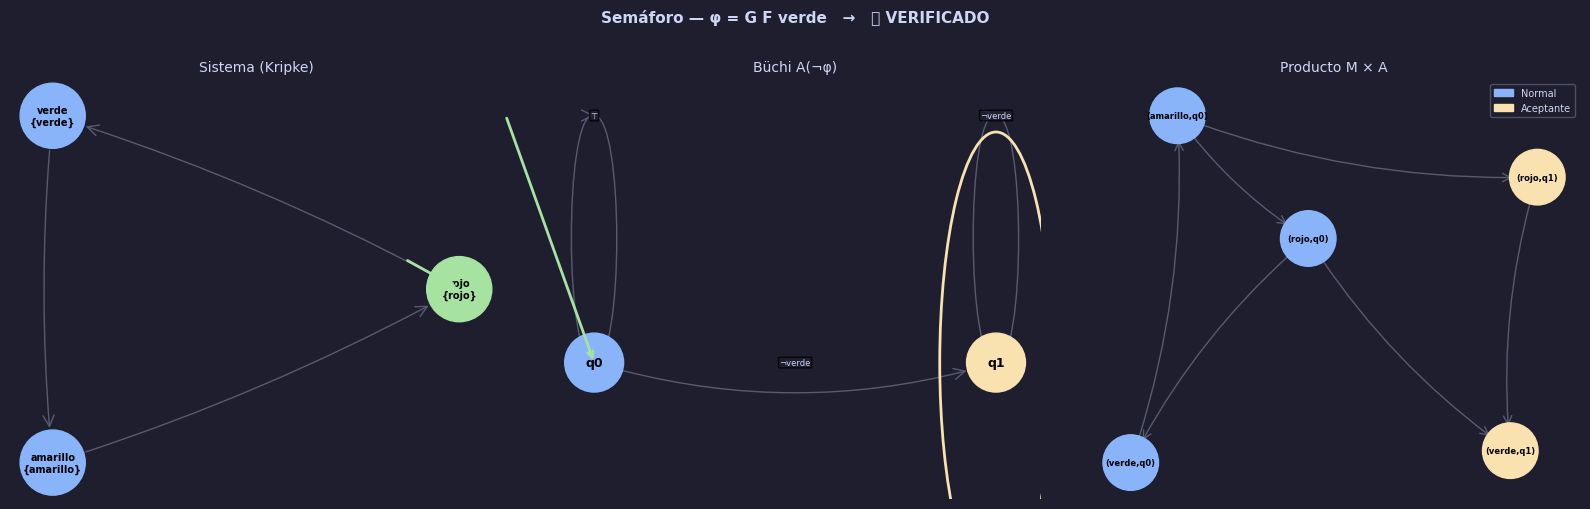

In [16]:
r1 = verify(semaforo, 'G F verde', verbose=False)
visualizar_verificacion(semaforo, r1, titulo='Semáforo — ')

---
## Visualización — Ejemplo 2: Exclusión Mutua

**φ₁ = G !(critica\_A & critica\_B)** — seguridad: nunca ambos en la sección crítica ✅

**φ₂ = G F critica\_A** — vivacidad: A siempre accede eventualmente ❌

El sistema garantiza la propiedad de seguridad porque no hay transición a un estado con ambos `critica_A` y `critica_B`. La vivacidad falla porque el sistema puede siempre darle acceso a B, ignorando a A indefinidamente — el contraejemplo muestra exactamente ese ciclo.

/tmp/ipykernel_1339460/1525180854.py:207: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


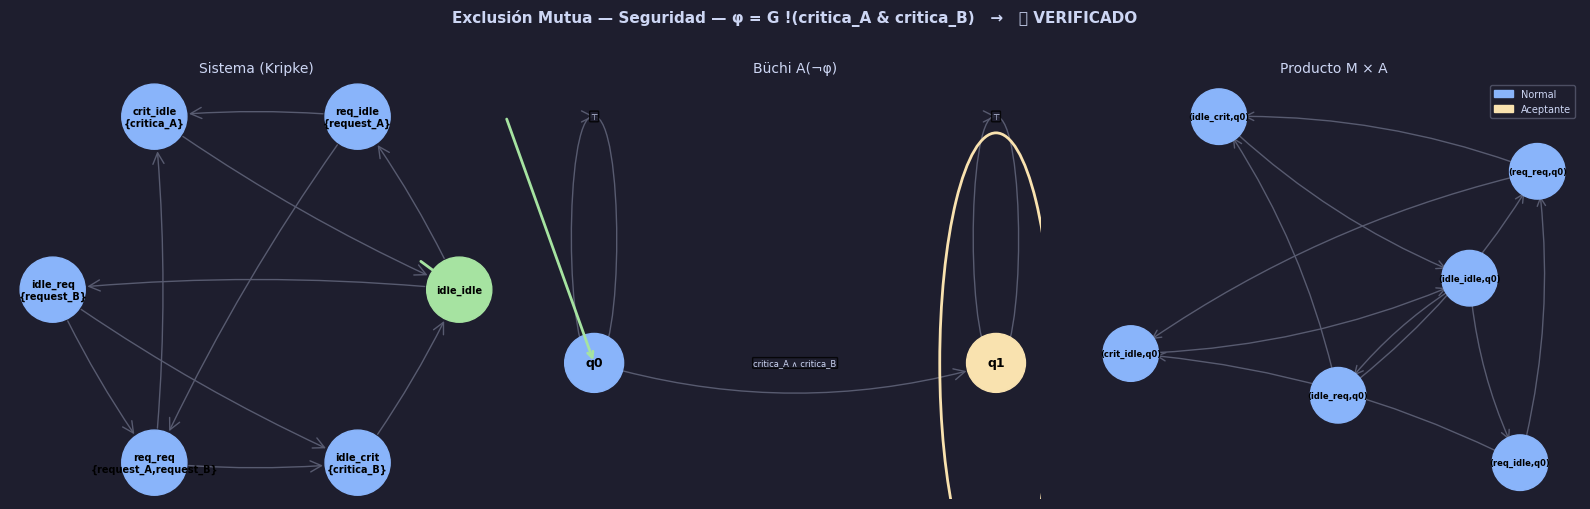

/tmp/ipykernel_1339460/1525180854.py:207: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jorvasquez/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


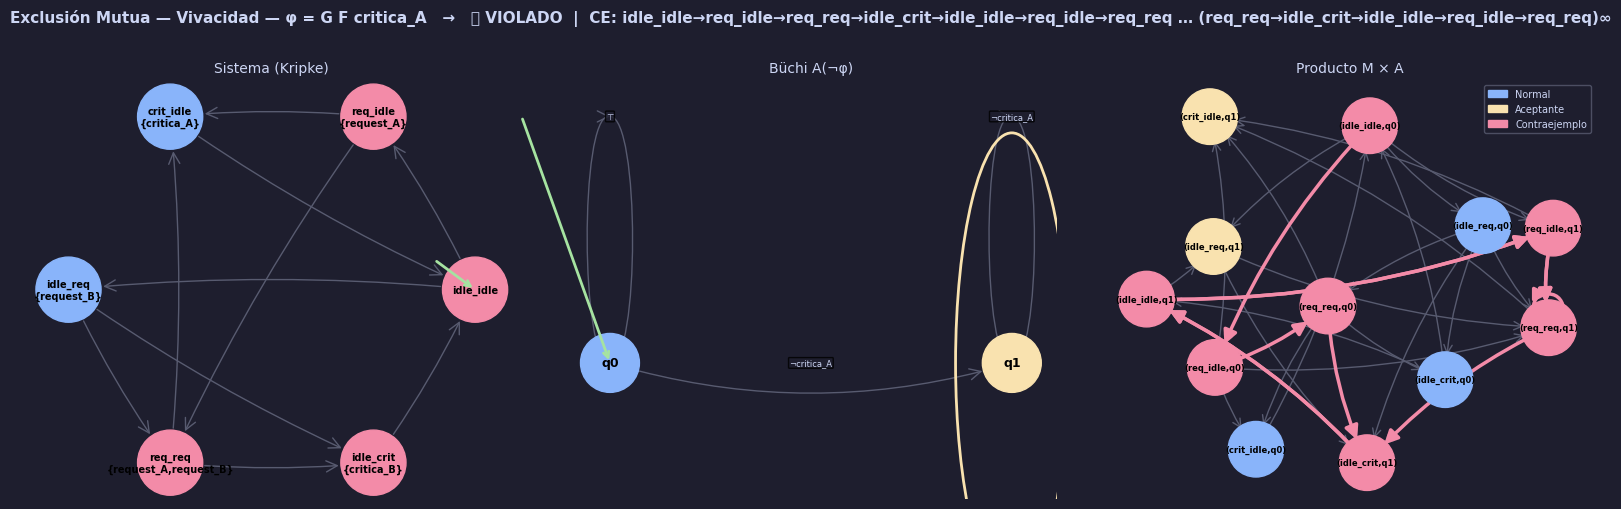

In [17]:
r_seg = verify(exclusion_mutua, 'G !(critica_A & critica_B)', verbose=False)
visualizar_verificacion(exclusion_mutua, r_seg, titulo='Exclusión Mutua — Seguridad — ')

r_viv = verify(exclusion_mutua, 'G F critica_A', verbose=False)
visualizar_verificacion(exclusion_mutua, r_viv, titulo='Exclusión Mutua — Vivacidad — ')

---
## Visualización — Ejemplo 3: Protocolo con Bug

**φ = G F grant** — "toda petición es eventualmente atendida" ❌

El sistema tiene el bug `request → deny → request → ...`. El verificador encuentra el ciclo `(request,q0) → (deny,q0) → (request,q0) → ...` que pasa por un estado aceptante infinitamente, sin que `grant` ocurra nunca. Ese ciclo **es el bug** — demostrado matemáticamente.

/tmp/ipykernel_1339460/1525180854.py:207: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


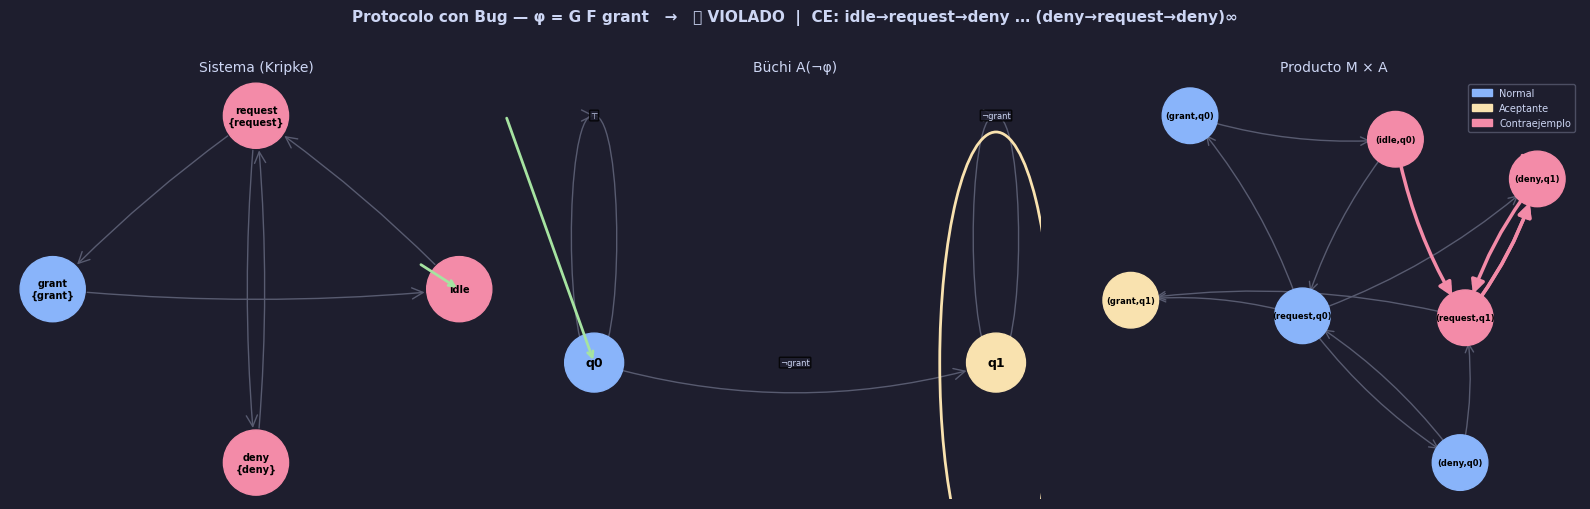

In [18]:
r_bug = verify(protocolo_bug, 'G F grant', verbose=False)
visualizar_verificacion(protocolo_bug, r_bug, titulo='Protocolo con Bug — ')

---
## Ejemplo 4: Tienda en Línea — Verificación de Flujo de Compra

### Motivación

Un modelo checker puede detectar bugs de concurrencia y liveness que el testing manual no encuentra. En este ejemplo modelamos el flujo de compra de una tienda en línea y verificamos propiedades de **seguridad** y **vivacidad**.

### Sistema (Estructura de Kripke)

```
idle → browsing → cart → checkout → processing ─── confirmed → shipping → delivered → idle
 ↑                  ↑                              │
 └── (abandona) ────┘                       failed ─────────── idle
```

### Bug del gateway de pagos

En `tienda_buggy` existe un estado `gateway_stuck` donde el procesador de pagos entra en un **bucle infinito de reintentos** — nunca responde ni falla limpiamente:

```
processing → gateway_stuck → gateway_stuck → gateway_stuck → ...  (NUNCA termina)
```

### Propiedades a verificar

| Propiedad | Semántica | `tienda_ok` | `tienda_buggy` |
|---|---|---|---|
| `G !(confirmed & failed)` | Nunca orden confirmada **y** fallida | ✅ | ✅ |
| `G !(confirmed & gateway_stuck)` | Nunca orden confirmada **y** atascada | ✅ | ✅ |
| `G F idle` | Siempre eventualmente regresa al estado idle | ✅ | ❌ **BUG** |
| `G F confirmed` | Toda sesión eventualmente confirma orden | ❌ | ❌ |

La propiedad `G F idle` es el **discriminador**: la cumple el sistema correcto pero el sistema con bug la viola, produciendo un contraejemplo que apunta exactamente al ciclo `gateway_stuck → gateway_stuck`.

In [19]:
# ── Ejemplo 4: Tienda Online ───────────────────────────────────

# Sistema CORRECTO: el pago puede fallar pero siempre limpiamente
tienda_ok = KripkeStructure(
    states=['idle', 'browsing', 'cart', 'checkout',
            'processing', 'confirmed', 'failed', 'shipping', 'delivered'],
    initial='idle',
    transitions=[
        ('idle',        'browsing'),
        ('browsing',    'cart'),
        ('browsing',    'idle'),        # usuario abandona
        ('cart',        'checkout'),
        ('checkout',    'processing'),
        ('processing',  'confirmed'),   # pago exitoso
        ('processing',  'failed'),      # pago fallido — limpiamente
        ('failed',      'idle'),        # regresa al inicio tras fallo
        ('confirmed',   'shipping'),
        ('shipping',    'delivered'),
        ('delivered',   'idle'),
    ],
    labels={
        'idle':       {'idle'},
        'browsing':   {'browsing'},
        'cart':       {'browsing', 'has_cart'},
        'checkout':   {'checkout'},
        'processing': {'processing'},
        'confirmed':  {'confirmed'},
        'failed':     {'failed'},
        'shipping':   {'shipping'},
        'delivered':  {'delivered'},
    }
)

# Sistema CON BUG: el gateway de pagos puede quedar atascado indefinidamente
tienda_buggy = KripkeStructure(
    states=['idle', 'browsing', 'cart', 'checkout',
            'processing', 'confirmed', 'gateway_stuck', 'shipping', 'delivered'],
    initial='idle',
    transitions=[
        ('idle',           'browsing'),
        ('browsing',       'cart'),
        ('browsing',       'idle'),
        ('cart',           'checkout'),
        ('checkout',       'processing'),
        ('processing',     'confirmed'),
        ('processing',     'gateway_stuck'),   # ← BUG: gateway cuelga
        ('gateway_stuck',  'gateway_stuck'),   # bucle infinito
        ('confirmed',      'shipping'),
        ('shipping',       'delivered'),
        ('delivered',      'idle'),
    ],
    labels={
        'idle':          {'idle'},
        'browsing':      {'browsing'},
        'cart':          {'browsing', 'has_cart'},
        'checkout':      {'checkout'},
        'processing':    {'processing'},
        'confirmed':     {'confirmed'},
        'gateway_stuck': {'processing', 'gateway_stuck'},
        'shipping':      {'shipping'},
        'delivered':     {'delivered'},
    }
)

# ── Verificaciones ─────────────────────────────────────────────
print('═' * 60)
print('TIENDA OK — sistema sin bug')
print('═' * 60)

r_ok_safety1 = verify(tienda_ok, 'G !(confirmed & failed)')
assert r_ok_safety1['result'] == True

print()
r_ok_safety2 = verify(tienda_ok, 'G !(confirmed & gateway_stuck)')
assert r_ok_safety2['result'] == True

print()
r_ok_liveness = verify(tienda_ok, 'G F idle')
assert r_ok_liveness['result'] == True

print()
r_ok_strong = verify(tienda_ok, 'G F confirmed')
assert r_ok_strong['result'] == False  # demasiado fuerte: usuario puede no comprar

print()
print('═' * 60)
print('TIENDA BUGGY — sistema con bug en gateway')
print('═' * 60)

print()
r_bug_safety = verify(tienda_buggy, 'G !(confirmed & gateway_stuck)')
assert r_bug_safety['result'] == True

print()
r_bug_liveness = verify(tienda_buggy, 'G F idle')
assert r_bug_liveness['result'] == False  # ← BUG detectado

print()
r_bug_strong = verify(tienda_buggy, 'G F confirmed')
assert r_bug_strong['result'] == False

print()
print('═' * 60)
print('RESUMEN TIENDA')
print('═' * 60)
print(f'  tienda_ok  + G !(confirmed & failed)      → {"✅" if r_ok_safety1["result"] else "❌"}')
print(f'  tienda_ok  + G !(confirmed & g_stuck)     → {"✅" if r_ok_safety2["result"] else "❌"}')
print(f'  tienda_ok  + G F idle                     → {"✅" if r_ok_liveness["result"] else "❌"}')
print(f'  tienda_ok  + G F confirmed                → {"✅" if r_ok_strong["result"] else "❌"}  (esperado ❌)')
print(f'  tienda_bug + G !(confirmed & g_stuck)     → {"✅" if r_bug_safety["result"] else "❌"}')
print(f'  tienda_bug + G F idle                     → {"✅" if r_bug_liveness["result"] else "❌"}  ← BUG')
print(f'  tienda_bug + G F confirmed                → {"✅" if r_bug_strong["result"] else "❌"}  (esperado ❌)')

════════════════════════════════════════════════════════════
TIENDA OK — sistema sin bug
════════════════════════════════════════════════════════════
  φ     = G !(confirmed & failed)
  ¬φ    = F((confirmed & failed))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 9 estados, 11 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G !(confirmed & gateway_stuck)
  ¬φ    = F((confirmed & gateway_stuck))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 9 estados, 11 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G F idle
  ¬φ    = F(G(!idle))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 17 estados, 29 transiciones
  → ✅ VERIFICADO: la propiedad se cumple en todos los comportamientos.

  φ     = G F confirmed
  ¬φ    = F(G(!confirmed))
  Büchi : Büchi(states=2, transitions=3, accepting={1})
  Producto: 17 estados, 30 transiciones
  → ❌ VIOL